# Taller: Super-Resolución con U-Net (128→512)

**Objetivo:** Entrenar una U-Net encoder-decoder para aumentar la resolución de imágenes de 128×128 a 512×512.

**Estrategia clave para pocas imágenes:**
- Encoder = ResNet-34 pre-entrenado (pesos congelados al inicio)
- Decoder = entrenado desde cero con datos propios
- Dataset sintético: tomas HR propias degradadas a LR
- Fine-tuning del encoder solo en la segunda fase

**Lo que necesitas para correr este taller:**
```

## Sección 1: Dataset

**Sobre el dataset — la pregunta más importante:**

Super-resolución tiene una ventaja enorme: **puedes generar tu propio dataset desde cero** con cualquier imagen de alta resolución. El pipeline es:

```
Imagen HR (512×512)  →  degradar  →  Imagen LR (128×128)
```

La degradación puede incluir:
- Downsampling bicúbico (simulación limpia)
- + blur gaussiano (simula lentes imperfectos)
- + ruido gaussiano (simula sensores)
- + compresión JPEG (simula fotos de internet)

**¿Cuántas imágenes necesito?**

| Imágenes HR | Estrategia recomendada | Calidad esperada |
|---|---|---|
| < 100 | Solo congelar encoder, augmentation agresivo | Baseline funcional |
| 100–500 | Encoder congelado + fine-tune al final | Buena |
| 500–2000 | Fine-tuning completo | Muy buena |
| > 2000 | Entrenar desde cero (o usar DIV2K) | Excelente |

**Datasets públicos útiles para comenzar:**
- [DIV2K](https://data.vision.ee.ethz.ch/cvl/DIV2K/) — 800 imágenes 2K, el estándar del campo
- BSD500 — 500 imágenes naturales
- Tiny-ImageNet — si ya lo tienes del curso anterior

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import functional as TF
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
from PIL import Image
import random
import numpy as np
import matplotlib.pyplot as plt
import os


from sr_dataset import SRDataset, show_sample_pairs, build_dataloaders

# Reproducibilidad
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# Cambia esta ruta a tu directorio de imágenes HR
IMG_DIR_TRAIN = 'images/train'  # o 'data/DIV2K_train_HR'
IMG_DIR_VAL = 'images/val'

exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
train_paths = sorted(p for p in Path(IMG_DIR_TRAIN).rglob('*') if p.suffix.lower() in exts)
val_paths   = sorted(p for p in Path(IMG_DIR_VAL).rglob('*')   if p.suffix.lower() in exts)

train_ds = SRDataset(train_paths, augment=True)
val_ds   = SRDataset(val_paths,   augment=False)

In [3]:
train_loader, val_loader = build_dataloaders(train_ds, val_ds, batch_size=4)

DataLoaders — train: 50 batches | val: 25 batches (batch_size=4)


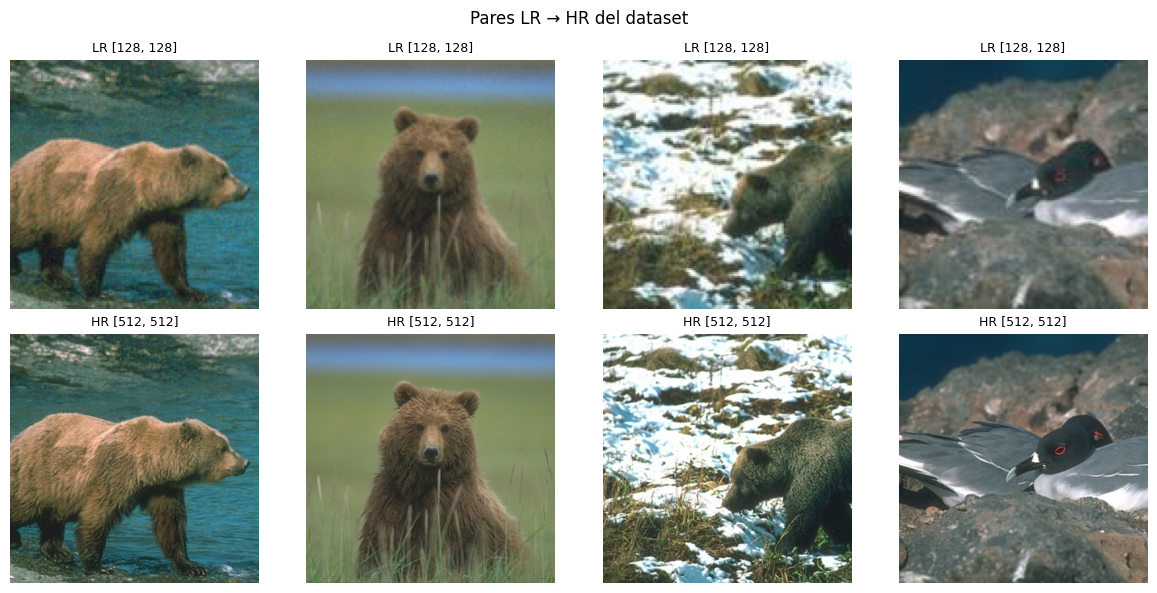

In [4]:
show_sample_pairs(train_ds, n=4)

## Sección 2: Arquitectura U-Net SR

La U-Net para SR tiene una diferencia importante respecto a la U-Net clásica (segmentación):
la salida debe ser **más grande** que la entrada, no del mismo tamaño.

**Estrategia de upsampling:**
- 4 pasos de upsampling ×2 en el decoder → 128 → 256 → 512
- Último bloque: **Pixel Shuffle** (sub-pixel convolution), que aprende a reorganizar
  canales en espacio — produce salidas más nítidas que el bilinear upsampling


In [10]:
class ConvBlock(nn.Module):
    """Bloque conv estándar: Conv → BN → ReLU × 2."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """
    Bloque de upsampling del decoder.

    Hace ×2 con bilinear (estable) + Conv para refinar,
    luego concatena con el skip connection del encoder.
    """

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = self.proj(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNetSR(nn.Module):
    """
    U-Net para super-resolución 128→512 con encoder ResNet-34 pre-entrenado.

    Encoder: capas layer1–layer4 de ResNet-34 (de 64 a 512 canales).
    Bottleneck: convblock extra a 1024ch.
    Decoder: 4 UpBlocks con skip connections.
    Head: bilinear ×4 → PixelShuffle ×2 → PixelShuffle ×2 → salida 512×512.

    Args:
        freeze_encoder: si True, congela SOLO el encoder (decoder entrena libre).
    """

    # Módulos del encoder agrupados para freeze/unfreeze selectivo
    _ENCODER_MODULES = ['enc_stem', 'enc1', 'enc2', 'enc3', 'enc4']

    def __init__(self, freeze_encoder: bool = True):
        super().__init__()

        # ---- Encoder (ResNet-34 pre-entrenado en ImageNet) ----
        backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        self.enc_stem = nn.Sequential(      # 128×128 → 32×32, 64ch
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.enc1 = backbone.layer1         # 32×32,  64ch
        self.enc2 = backbone.layer2         # 16×16, 128ch
        self.enc3 = backbone.layer3         #  8×8,  256ch
        self.enc4 = backbone.layer4         #  4×4,  512ch

        # ---- Bottleneck ----
        self.bottleneck = ConvBlock(512, 1024)

        # ---- Decoder ----
        #              in_ch  skip_ch  out_ch
        self.dec4 = UpBlock(1024,  512,  512)
        self.dec3 = UpBlock( 512,  256,  256)
        self.dec2 = UpBlock( 256,  128,  128)
        self.dec1 = UpBlock( 128,   64,   64)

        # ---- Head: 32×32 → 512×512 con dos PixelShuffle ×2 ----
        #
        # FIX: entre los dos PixelShuffle se amplía a 32ch antes de volver a 12.
        # Con solo 3ch la capacidad era insuficiente → color shift y blur.
        #
        #  [B, 64, 32, 32]
        #    → Upsample ×4 bilinear  → [B,  64, 128, 128]
        #    → Conv + ReLU           → [B,  64, 128, 128]
        #    → Conv 64→12            → [B,  12, 128, 128]
        #    → PixelShuffle(2)       → [B,   3, 256, 256]
        #    → Conv 3→32 + ReLU      → [B,  32, 256, 256]   ← ampliado (era 3→12)
        #    → Conv 32→12            → [B,  12, 256, 256]
        #    → PixelShuffle(2)       → [B,   3, 512, 512]
        #    → Sigmoid               → [0, 1]
        self.head = nn.Sequential(
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 12, 3, padding=1),
            nn.PixelShuffle(2),                      # → [B,  3, 256, 256]
            nn.Conv2d(3, 32, 3, padding=1, bias=False),  # ampliar antes del 2do shuffle
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 12, 3, padding=1),
            nn.PixelShuffle(2),                      # → [B,  3, 512, 512]
            nn.Sigmoid(),
        )

        # FIX: congelar SOLO el encoder, DESPUÉS de definir decoder y head.
        # El orden importa: self.parameters() incluye todo lo definido hasta aquí.
        if freeze_encoder:
            self._set_encoder_grad(requires_grad=False)

    # ------------------------------------------------------------------
    def _set_encoder_grad(self, requires_grad: bool) -> None:
        """Activa o desactiva gradientes SOLO en los módulos del encoder."""
        for name in self._ENCODER_MODULES:
            for p in getattr(self, name).parameters():
                p.requires_grad = requires_grad

    def unfreeze_encoder(self) -> None:
        """Descongela el encoder para fine-tuning completo (fase 2)."""
        self._set_encoder_grad(requires_grad=True)
        print("Encoder descongelado — fine-tuning completo activado.")

    # ------------------------------------------------------------------
    def forward(self, x):
        # x: [B, 3, 128, 128]
        s0 = self.enc_stem(x)   # [B,  64, 32, 32]
        s1 = self.enc1(s0)      # [B,  64, 32, 32]
        s2 = self.enc2(s1)      # [B, 128, 16, 16]
        s3 = self.enc3(s2)      # [B, 256,  8,  8]
        s4 = self.enc4(s3)      # [B, 512,  4,  4]

        b  = self.bottleneck(s4)   # [B, 1024, 4, 4]

        d4 = self.dec4(b,  s4)    # [B,  512, 8,  8]
        d3 = self.dec3(d4, s3)    # [B,  256, 16, 16]
        d2 = self.dec2(d3, s2)    # [B,  128, 32, 32]
        d1 = self.dec1(d2, s1)    # [B,   64, 32, 32]

        return self.head(d1)       # [B,    3, 512, 512]


# ── Verificación ──────────────────────────────────────────────────────────────
model = UNetSR(freeze_encoder=True).to(DEVICE)

x_test = torch.randn(2, 3, 128, 128).to(DEVICE)
with torch.no_grad():
    out = model(x_test)
print(f"Input:  {x_test.shape}")
print(f"Output: {out.shape}")   # esperado: [2, 3, 512, 512]

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
frozen    = total - trainable
print(f"\nParámetros entrenables : {trainable/1e6:.2f}M  (decoder + head)")
print(f"Parámetros congelados  : {frozen/1e6:.2f}M  (encoder ResNet-34)")
print(f"Total                  : {total/1e6:.2f}M")

# Verificar que el encoder está realmente congelado
enc_grad = sum(p.numel() for n, p in model.named_parameters()
               if p.requires_grad and any(n.startswith(m) for m in UNetSR._ENCODER_MODULES))
assert enc_grad == 0, "❌ BUG: el encoder tiene gradientes activos en Fase 1"
print("\n✅ Encoder congelado correctamente — solo decoder y head entrenan en Fase 1")


Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 512, 512])

Parámetros entrenables : 24.31M  (decoder + head)
Parámetros congelados  : 21.28M  (encoder ResNet-34)
Total                  : 45.59M

✅ Encoder congelado correctamente — solo decoder y head entrenan en Fase 1


## Sección 3: Función de pérdida

Solo MSE/L1 produce resultados borrosos porque promedian soluciones posibles.
Combinamos tres pérdidas complementarias:

- **L1** — reconstrucción pixel a pixel (más estable que MSE para SR)
- **Perceptual (VGG)** — diferencia en espacio de features de VGG16,
  preserva texturas y estructuras de alto nivel
- **SSIM** — métrica de similaridad estructural, mantiene bordes

In [11]:
class VGGPerceptualLoss(nn.Module):
    """
    Pérdida perceptual usando features intermedias de VGG16.
    
    Extrae features de las capas relu2_2 y relu3_3 (buen balance
    entre detalles finos y estructuras de alto nivel).
    """

    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        # relu2_2 = índice 9,  relu3_3 = índice 16
        self.slice1 = nn.Sequential(*list(vgg.children())[:10]).eval()
        self.slice2 = nn.Sequential(*list(vgg.children())[10:17]).eval()
        for p in self.parameters():
            p.requires_grad = False

        # Normalización ImageNet (VGG fue entrenado con estas stats)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        self.register_buffer('mean', mean)
        self.register_buffer('std', std)

    def forward(self, pred, target):
        # Normalizar al espacio de VGG
        p = (pred   - self.mean) / self.std
        t = (target - self.mean) / self.std

        f1_p = self.slice1(p)
        f1_t = self.slice1(t)
        loss  = F.l1_loss(f1_p, f1_t)

        f2_p = self.slice2(f1_p)
        f2_t = self.slice2(f1_t)
        loss += F.l1_loss(f2_p, f2_t)

        return loss


def ssim_loss(pred: torch.Tensor, target: torch.Tensor, window_size: int = 11) -> torch.Tensor:
    """
    SSIM diferenciable (1 - SSIM, para usarla como pérdida a minimizar).
    Implementación simplificada sin dependencias externas.
    """
    C1, C2 = 0.01 ** 2, 0.03 ** 2

    # Kernel gaussiano
    sigma = 1.5
    coords = torch.arange(window_size, dtype=pred.dtype, device=pred.device)
    coords -= window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    kernel = g.unsqueeze(0) * g.unsqueeze(1)  # [W, W]
    kernel = kernel.expand(pred.shape[1], 1, window_size, window_size)

    pad = window_size // 2

    def conv(x):
        return F.conv2d(x, kernel, padding=pad, groups=pred.shape[1])

    mu_p, mu_t   = conv(pred), conv(target)
    mu_pp, mu_tt = mu_p ** 2, mu_t ** 2
    mu_pt        = mu_p * mu_t

    sigma_pp = conv(pred   ** 2) - mu_pp
    sigma_tt = conv(target ** 2) - mu_tt
    sigma_pt = conv(pred * target) - mu_pt

    numerator   = (2 * mu_pt + C1) * (2 * sigma_pt + C2)
    denominator = (mu_pp + mu_tt + C1) * (sigma_pp + sigma_tt + C2)
    ssim_map    = numerator / (denominator + 1e-8)

    return 1.0 - ssim_map.mean()


class SRLoss(nn.Module):
    """
    Pérdida combinada: L1 + perceptual + SSIM.

    Pesos por defecto calibrados para SR natural:
    - w_l1=1.0, w_perc=0.1, w_ssim=0.2

    Para texturas muy detalladas, aumenta w_perc.
    Para preservar color exacto, aumenta w_l1.
    """

    def __init__(self, w_l1: float = 1.0, w_perc: float = 0.1, w_ssim: float = 0.2):
        super().__init__()
        self.w_l1   = w_l1
        self.w_perc = w_perc
        self.w_ssim = w_ssim
        self.perc   = VGGPerceptualLoss()

    def forward(self, pred, target):
        l1   = F.l1_loss(pred, target)
        perc = self.perc(pred, target)
        ssim = ssim_loss(pred, target)
        total = self.w_l1 * l1 + self.w_perc * perc + self.w_ssim * ssim
        return total, {'l1': l1.item(), 'perceptual': perc.item(), 'ssim': ssim.item()}


criterion = SRLoss(w_l1=1.0, w_perc=0.1, w_ssim=0.2).to(DEVICE)
print('Función de pérdida lista.')

Función de pérdida lista.


## Sección 4: Entrenamiento

**Estrategia en dos fases para pocos datos:**

**Fase 1 (10–20 épocas):** encoder congelado, lr alto → el decoder aprende rápido.

**Fase 2 (5–10 épocas):** encoder descongelado, lr 10× menor → fine-tuning fino.

In [12]:
def compute_psnr(pred: torch.Tensor, target: torch.Tensor) -> float:
    """PSNR en dB — métrica estándar de SR. Mayor es mejor (30+ dB es bueno)."""
    with torch.no_grad():
        mse = F.mse_loss(pred.clamp(0, 1), target.clamp(0, 1))
        if mse == 0:
            return float('inf')
        return 10 * torch.log10(1.0 / mse).item()


def train_epoch(model, loader, optimizer, criterion, device, writer, global_step):
    model.train()
    total_loss, total_psnr = 0.0, 0.0

    for lr_img, hr_img in loader:
        lr_img = lr_img.to(device, non_blocking=True)
        hr_img = hr_img.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(lr_img)
        loss, loss_dict = criterion(pred, hr_img)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_psnr += compute_psnr(pred.detach(), hr_img)

        # Log a TensorBoard cada paso
        writer.add_scalar('train/loss',       loss.item(),                  global_step)
        writer.add_scalar('train/loss_l1',    loss_dict['l1'],              global_step)
        writer.add_scalar('train/loss_perc',  loss_dict['perceptual'],      global_step)
        writer.add_scalar('train/loss_ssim',  loss_dict['ssim'],            global_step)
        global_step += 1

    n = len(loader)
    return total_loss / n, total_psnr / n, global_step


@torch.no_grad()
def val_epoch(model, loader, criterion, device, writer, epoch):
    model.eval()
    total_loss, total_psnr = 0.0, 0.0

    for batch_idx, (lr_img, hr_img) in enumerate(loader):
        lr_img = lr_img.to(device, non_blocking=True)
        hr_img = hr_img.to(device, non_blocking=True)

        pred = model(lr_img)
        loss, _ = criterion(pred, hr_img)

        total_loss += loss.item()
        total_psnr += compute_psnr(pred, hr_img)

        # Guardar grilla de imágenes en TensorBoard (primer batch de cada época)
        if batch_idx == 0:
            from torchvision.utils import make_grid
            n_show = min(4, lr_img.size(0))
            lr_up  = F.interpolate(lr_img[:n_show], size=(512, 512), mode='bicubic', align_corners=False)
            grid_lr   = make_grid(lr_up.clamp(0, 1),    nrow=n_show)
            grid_pred = make_grid(pred[:n_show].clamp(0, 1), nrow=n_show)
            grid_hr   = make_grid(hr_img[:n_show].clamp(0, 1), nrow=n_show)
            writer.add_image('val/LR_bicubic', grid_lr,   epoch)
            writer.add_image('val/pred_SR',    grid_pred, epoch)
            writer.add_image('val/HR_gt',      grid_hr,   epoch)

    n = len(loader)
    val_loss = total_loss / n
    val_psnr = total_psnr / n
    writer.add_scalar('val/loss', val_loss, epoch)
    writer.add_scalar('val/psnr', val_psnr, epoch)
    return val_loss, val_psnr

In [14]:
# ============================================================
#  Configuración del entrenamiento
# ============================================================
EPOCHS_PHASE1  = 20    # Encoder congelado
EPOCHS_PHASE2  = 10    # Encoder descongelado (fine-tuning)
LR_PHASE1      = 1e-3
LR_PHASE2      = 1e-4
LR_PHASE2_ENC  = 1e-5  # Encoder recibe LR 10× menor en fine-tuning
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

writer    = SummaryWriter('runs/sr_unet')
model     = UNetSR(freeze_encoder=True).to(DEVICE)
criterion = SRLoss(w_l1=1.0, w_perc=0.1, w_ssim=0.2).to(DEVICE)

# Fase 1: solo parámetros entrenables (decoder + head)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE1
)

# ============================================================
#  Fase 1: Decoder-only (encoder congelado)
# ============================================================
print('\n=== FASE 1: Decoder-only (encoder congelado) ===-')
best_psnr   = 0.0
global_step = 0

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_psnr, global_step = train_epoch(
        model, train_loader, optimizer, criterion, DEVICE, writer, global_step
    )
    va_loss, va_psnr = val_epoch(
        model, val_loader, criterion, DEVICE, writer, epoch
    )
    scheduler.step()

    writer.add_scalar('train/psnr', tr_psnr, epoch)
    writer.add_scalar('lr/decoder', optimizer.param_groups[0]['lr'], epoch)

    print(f'Época {epoch:02d}/{EPOCHS_PHASE1} | '
          f'train loss={tr_loss:.4f} psnr={tr_psnr:.2f}dB | '
          f'val loss={va_loss:.4f} psnr={va_psnr:.2f}dB')

    if va_psnr > best_psnr:
        best_psnr = va_psnr
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'psnr': best_psnr},
                   CHECKPOINT_DIR / 'best_phase1.pt')

print(f'\nFase 1 completada. Mejor PSNR val: {best_psnr:.2f} dB')

# ============================================================
#  Fase 2: Fine-tuning completo con LR diferenciados
# ============================================================
#
#  ¿Por qué LRs distintos para encoder y decoder?
#
#  El encoder ya tiene buenos features (pre-entrenado en ImageNet).
#  Un LR alto lo sobreescribiría y perderíamos esa ventaja.
#  El decoder fue entrenado desde cero en Fase 1 — puede seguir
#  aprendiendo a ritmo normal.
#
#  Regla práctica en transfer learning: encoder ≈ LR/10 del decoder.
#
print('\n=== FASE 2: Fine-tuning completo (encoder descongelado) ===')
model.unfreeze_encoder()

enc_params = [p for n, p in model.named_parameters()
              if any(n.startswith(m) for m in UNetSR._ENCODER_MODULES)]
dec_params = [p for n, p in model.named_parameters()
              if not any(n.startswith(m) for m in UNetSR._ENCODER_MODULES)]

optimizer2 = torch.optim.AdamW([
    {'params': enc_params, 'lr': LR_PHASE2_ENC},   # 1e-5 — encoder
    {'params': dec_params, 'lr': LR_PHASE2},        # 1e-4 — decoder + head
], weight_decay=1e-4)

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=EPOCHS_PHASE2
)

print(f'  encoder params : {sum(p.numel() for p in enc_params)/1e6:.2f}M  @ lr={LR_PHASE2_ENC}')
print(f'  decoder params : {sum(p.numel() for p in dec_params)/1e6:.2f}M  @ lr={LR_PHASE2}')

best_psnr_p2 = 0.0

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, tr_psnr, global_step = train_epoch(
        model, train_loader, optimizer2, criterion, DEVICE, writer, global_step
    )
    va_loss, va_psnr = val_epoch(
        model, val_loader, criterion, DEVICE, writer, EPOCHS_PHASE1 + epoch
    )
    scheduler2.step()

    writer.add_scalar('lr/encoder', optimizer2.param_groups[0]['lr'], EPOCHS_PHASE1 + epoch)
    writer.add_scalar('lr/decoder', optimizer2.param_groups[1]['lr'], EPOCHS_PHASE1 + epoch)

    print(f'Época {epoch:02d}/{EPOCHS_PHASE2} | '
          f'train loss={tr_loss:.4f} psnr={tr_psnr:.2f}dB | '
          f'val loss={va_loss:.4f} psnr={va_psnr:.2f}dB')

    if va_psnr > best_psnr_p2:
        best_psnr_p2 = va_psnr
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'psnr': best_psnr_p2},
                   CHECKPOINT_DIR / 'best_phase2.pt')

writer.close()
print(f'\nFase 2 completada. Mejor PSNR val: {best_psnr_p2:.2f} dB')



=== FASE 1: Decoder-only (encoder congelado) ===-
Época 01/20 | train loss=0.6033 psnr=12.05dB | val loss=0.6108 psnr=12.18dB
Época 02/20 | train loss=0.5462 psnr=14.12dB | val loss=0.5339 psnr=14.79dB
Época 03/20 | train loss=0.5104 psnr=15.92dB | val loss=0.4940 psnr=17.49dB
Época 04/20 | train loss=0.4981 psnr=16.58dB | val loss=0.4864 psnr=18.16dB
Época 05/20 | train loss=0.4860 psnr=17.20dB | val loss=0.4814 psnr=18.12dB
Época 06/20 | train loss=0.4765 psnr=17.65dB | val loss=0.4695 psnr=19.21dB
Época 07/20 | train loss=0.4787 psnr=17.75dB | val loss=0.4764 psnr=18.69dB
Época 08/20 | train loss=0.4737 psnr=17.86dB | val loss=0.4683 psnr=19.15dB
Época 09/20 | train loss=0.4603 psnr=18.50dB | val loss=0.4579 psnr=19.75dB
Época 10/20 | train loss=0.4688 psnr=18.25dB | val loss=0.4520 psnr=20.11dB
Época 11/20 | train loss=0.4581 psnr=18.71dB | val loss=0.4511 psnr=20.15dB
Época 12/20 | train loss=0.4595 psnr=18.69dB | val loss=0.4503 psnr=20.07dB
Época 13/20 | train loss=0.4578 psnr=

Modelo cargado. PSNR reportado: 20.61 dB


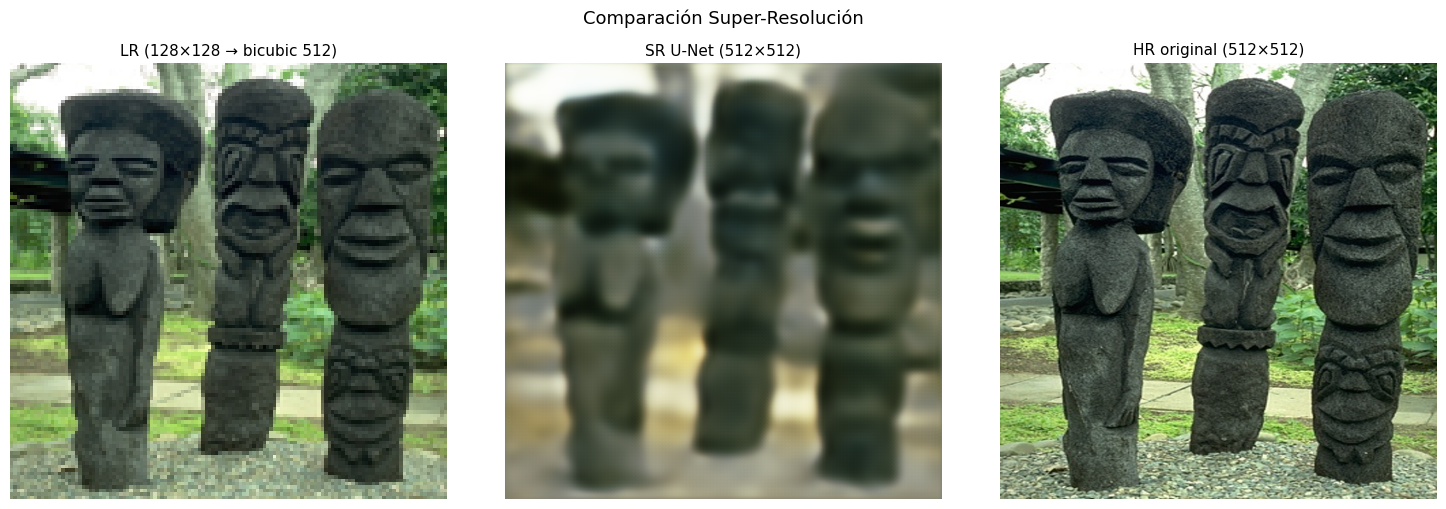

In [15]:
## Sección 5: Evaluación e inferencia

def load_best_model(checkpoint_path: str, device: str) -> UNetSR:
    model = UNetSR(freeze_encoder=False).to(device)
    ckpt  = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f'Modelo cargado. PSNR reportado: {ckpt["psnr"]:.2f} dB')
    return model


@torch.no_grad()
def super_resolve(model: UNetSR, img_path: str, device: str) -> tuple:
    """Infiere SR sobre una imagen real (sin degradación artificial)."""
    img_hr = Image.open(img_path).convert('RGB')
    # Generar LR artificialmente para demo
    img_lr = img_hr.resize((128, 128), Image.BICUBIC)

    lr_t = transforms.ToTensor()(img_lr).unsqueeze(0).to(device)
    sr_t = model(lr_t).squeeze(0).cpu().clamp(0, 1)

    return img_lr, sr_t


def visualize_comparison(img_lr, sr_tensor, hr_path=None):
    """Muestra LR | SR | HR (si se provee) lado a lado."""
    cols = 3 if hr_path else 2
    fig, axes = plt.subplots(1, cols, figsize=(cols * 5, 5))

    axes[0].imshow(img_lr)
    axes[0].set_title('LR (128×128 → bicubic 512)', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(sr_tensor.permute(1, 2, 0))
    axes[1].set_title('SR U-Net (512×512)', fontsize=11)
    axes[1].axis('off')

    if hr_path:
        hr_img = Image.open(hr_path).resize((512, 512), Image.BICUBIC)
        axes[2].imshow(hr_img)
        axes[2].set_title('HR original (512×512)', fontsize=11)
        axes[2].axis('off')

    plt.suptitle('Comparación Super-Resolución', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ---- Cargar modelo y hacer inferencia ----
best_model = load_best_model('checkpoints/best_phase2.pt', DEVICE)

# Prueba con una imagen del set de validación
test_img_path = str(val_ds.paths[0])
lr_img, sr_out = super_resolve(best_model, test_img_path, DEVICE)
visualize_comparison(lr_img, sr_out, hr_path=test_img_path)

In [16]:
@torch.no_grad()
def evaluate_full_val(model, val_loader, device, n_batches=None):
    """
    Evalúa PSNR y SSIM sobre el set de validación completo.
    Compara U-Net SR vs baseline bicúbico.
    """
    model.eval()
    psnr_sr, psnr_bic = [], []
    ssim_sr, ssim_bic = [], []

    for i, (lr_img, hr_img) in enumerate(val_loader):
        if n_batches and i >= n_batches:
            break
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        # Predicción del modelo
        sr = model(lr_img).clamp(0, 1)
        # Baseline: bicúbico simple
        bic = F.interpolate(lr_img, size=(512, 512), mode='bicubic',
                            align_corners=False).clamp(0, 1)

        psnr_sr.append(compute_psnr(sr, hr_img))
        psnr_bic.append(compute_psnr(bic, hr_img))
        ssim_sr.append(1.0 - ssim_loss(sr, hr_img).item())
        ssim_bic.append(1.0 - ssim_loss(bic, hr_img).item())

    results = {
        'PSNR SR':       np.mean(psnr_sr),
        'PSNR Bicubic':  np.mean(psnr_bic),
        'SSIM SR':       np.mean(ssim_sr),
        'SSIM Bicubic':  np.mean(ssim_bic),
    }
    print('\n=== Evaluación comparativa ===')
    print(f'{"Métrica":<20} {"U-Net SR":>12} {"Bicúbico":>12} {"Mejora":>10}')
    print('-' * 56)
    print(f'{"PSNR (dB)":<20} {results["PSNR SR"]:>12.2f} {results["PSNR Bicubic"]:>12.2f} '
          f'{results["PSNR SR"] - results["PSNR Bicubic"]:>+10.2f}')
    print(f'{"SSIM":<20} {results["SSIM SR"]:>12.4f} {results["SSIM Bicubic"]:>12.4f} '
          f'{results["SSIM SR"] - results["SSIM Bicubic"]:>+10.4f}')
    return results


results = evaluate_full_val(best_model, val_loader, DEVICE)


=== Evaluación comparativa ===
Métrica                  U-Net SR     Bicúbico     Mejora
--------------------------------------------------------
PSNR (dB)                   20.55        25.88      -5.33
SSIM                       0.5505       0.7209    -0.1703
